# 2. Solving a Murder Mystery using Hierarchical Bayesian Models

Solve the M&M's murder mystery problem presented in class, by plotting the posterior distribution for the $\theta$ paramater for the probability that the victim's pack of M&M's came from Factory A.

### Our Data
We want to figure out from which factory a bag of M&Ms come from: factory A or B.

For colour vector \[Blue, Orange, Green, Yellow, Red, Borwn\], the original bag has
- $\vec{x}= [9, 9, 8, 6, 7, 5]$ with $n_x=45$

and we collect 10 bags from factory A and B respectively, to find
- $\vec{C_A}=[115,115,54,52,55,55]$ with $N_A=446$
- $\vec{C_B}=[95,98,87,57,57,55]$ with $N_B=449$.



### Our Model
Let us define our hierarchical bayseian model.

The paramaters are
- population level: $\theta\in [0,1]$ the probability the bag came from factory A;
- latent-level: $F\in\{A,B\}$ the factoy that produced the poisoned pack
- factory-level (nuisance params): $\vec{\lambda_A} = [\lambda_{A, Blue}, \lambda_{A, Orange}, ...]$ and $\vec{\lambda_B}$ the intrinsic colour distribution produced by each factory.

The priors are
- $P(\lambda_A)\propto \text{Dirichlet}(\alpha_0)$ where $\alpha_0=(1,1,1,1,1,1)$ defines a flat prior,
- $P(\lambda_B)$ same as above
- $P(\theta)\propto \text{Beta(a,b)}$ where $a=b=1$ defines a flat prior.

The likelihoods are
- $P(\vec{C_A}|\vec{\lambda}_A)\propto\text{Multinomial}(N_A, \vec{\lambda}_A)$
- $P(\vec{C_B}|\vec{\lambda}_B)\propto\text{Multinomial}(N_B, \vec{\lambda}_B)$
- $P(F|\theta)\propto \text{Bernoulli}(\theta)$ where $F$ is factory A or B, and
- $P(\vec{x}|F=A,\lambda_A)\propto \text{Multinomial}(n_x, \vec{\lambda_A})$,
- $P(\vec{x}|F=B,\lambda_B)\propto \text{Multinomial}(n_x, \vec{\lambda_B})$



Thus, using the product rule $P(a,b)=P(a|b)P(b)$, we get the posterior
$$P(\theta,F,\vec{\lambda_A},\vec{\lambda_B}| \vec{x},\vec{C_A},\vec{C_A})\propto P(\theta)P(F|\theta)P(\vec{\lambda_A})P(\vec{\lambda_B})P(\vec{C_A}|\vec{\lambda_A})P(\vec{C_B}|\vec{\lambda_B})P(\vec{x}|F,\vec{\lambda_A},\vec{\lambda_B})$$

such that we get the following by marginalizing

$$P(\theta|\vec{x},\vec{C_A},\vec{C_A})\propto \sum_{F\in (A,B)} \int \int P(\theta,F,\vec{\lambda_A},\vec{\lambda_B}| \vec{x},\vec{C_A},\vec{C_A}) d\vec{\lambda_A} d\vec{\lambda_B}$$

Using Bayes' rule, we get
$$
P(\theta \mid \vec{x}, \vec{C}_{A}, \vec{C}_{B}) \propto P(\vec{x} \mid \theta, \vec{C}_{A}, \vec{C}_{B}) \, P(\theta)
$$
where we break up $P(\vec{x} \mid \theta, \vec{C}_{A}, \vec{C}_{B})$ into the $F=A$ and $F=B$ cases, such that
$$
P(\vec{x} \mid \theta, \vec{C}_{A}, \vec{C}_{B}) = \underbrace{P(\vec{x} \mid F=A, \vec{C}_{A})}_{L_A} \, \underbrace{P(F=A \mid \theta)}_{\theta \text{: Bernoulli success}} \quad \underbrace{P(\vec{x} \mid F=B, \vec{C}_{B})}_{L_B} \, \underbrace{P(F=B \mid \theta)}_{(1-\theta)\text{: Bernoulli failure}}
$$

Let us calculate $L_A$.
$$
\begin{aligned}
P(\vec{x} \mid F=A, \vec{C}_{A})
&= \int P(\vec{x} \mid \vec{\lambda}_A) \, P(\vec{\lambda}_A \mid \vec{C}_A) \, d\vec{\lambda}_A \quad \text{from Baye's rule}\\
&\propto \int \underbrace{P(\vec{x}\mid\vec{\lambda}_A)}_{\text{Mult}(n_x, \vec{\lambda}_A)}\, \underbrace{\underbrace{P(\vec{C}_A\mid\vec{\lambda}_A)}_{\text{Mult}(n_A, \vec{\lambda}_A)} \, \underbrace{P(\vec{\lambda}_A)}_{\text{Dir}(\vec{\alpha}_{0})}}_{\propto \,\text{Dir}(\vec{\alpha_0}+\vec{C}_A)} \, d\vec{x}_A \\
&\propto \int \text{Mult}(n_x, \vec{\lambda}_A)\,\text{Dir}(\vec{\alpha}_0+\vec{C}_A)\,d\vec{\lambda}_A\quad \text{which is the Multinomial-Dirichlet predictive}\\
&= \frac{n_x!}{\prod_k x_k!} \, \frac{\Gamma\left(\sum_k (\alpha_{0,k} + C_{A,k})\right)}{\Gamma\left(\sum_k (\alpha_{0,k} + C_{A,k} + n_x)\right)} \, \prod_k \frac{\Gamma(\alpha_{0,k} + C_{A,k} + x_k)}{\Gamma(\alpha_{0,k} + C_{A,k})} = L_A
\end{aligned}
$$

Similarly, we get $L_B$:
$$
P(\vec{x} \mid F=B, \vec{C}_{B}) = \frac{n_x!}{\prod_k x_k!} \, \frac{\Gamma\left(\sum_k (\alpha_{0,k} + C_{B,k})\right)}{\Gamma\left(\sum_k (\alpha_{0,k} + C_{B,k} + n_x)\right)} \, \prod_k \frac{\Gamma(\alpha_{0,k} + C_{B,k} + x_k)}{\Gamma(\alpha_{0,k} + C_{B,k})} = L_B
$$

So, having marginalized over latent parameters $F, \vec{\lambda}_A$ and $\vec{\lambda}_B$, we get
$$
\begin{aligned}
P(\theta \mid \vec{x}, \vec{C}_{A}, \vec{C}_{B}) &\propto P(\vec{x} \mid \theta, \vec{C}_{A}, \vec{C}_{B}) \, P(\theta) \\
&= \left[ L_A \, \theta + L_B \, (1-\theta) \right] {P(\theta)}\quad {\text{where $P(\theta)=$Beta}(a=1,\, b=1)=\theta^{a-1} (1-\theta)^{b-1}=1} \\
&= L_A \, \theta + L_B \, (1-\theta)
\end{aligned}
$$

Next, we can find the normalization factor
$$
\begin{aligned}
N &= \int_0^1 P(\theta\mid \vec{x}, \vec{C}_A,\vec{C}_B)\, d\theta = \int_0^1 ((L_A-L_B)\theta + L_B)\,d\theta\\
&= \left[(L_A-L_B)\frac{1}{2}\theta^2 + L_B\theta \right]_0^1= \frac{L_A+L_B}{2}
\end{aligned}
$$

to get pdf
$$
\boxed{P(\theta\mid \vec{x}, \vec{C}_A,\vec{C}_B)= \frac{2((L_A-L_B)\theta +L_B)}{L_A+L_B} }.
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln

For numerical stability, we calculate $L_A$ and $L_B$ using $\text{log}$, such that
$$
\begin{aligned}
\log(L_A)&=\log\left(\frac{n_x!}{\prod_k x_k!} \, \frac{\Gamma\left(\sum_k (\alpha_{0,k} + C_{A,k})\right)}{\Gamma\left(\sum_k (\alpha_{0,k} + C_{A,k} + n_x)\right)} \, \prod_k \frac{\Gamma(\alpha_{0,k} + C_{A,k} + x_k)}{\Gamma(\alpha_{0,k} + C_{A,k})}\right)\\
&=\underbrace{\log\left(\frac{n_x!}{\prod_k x_k!}\right)}_{\text{term 1}} + \underbrace{\log\left(\frac{\Gamma\left(\sum_k (\alpha_{0,k} + C_{A,k})\right)}{\Gamma\left(\sum_k (\alpha_{0,k} + C_{A,k} + x_k)\right)}\right)}_{\text{term 2}} +\underbrace{\log\left(\prod_k \frac{\Gamma(\alpha_{0,k} + C_{A,k} + x_k)}{\Gamma(\alpha_{0,k} + C_{A,k})}\right)}_{\text{term 3}}
\end{aligned}
$$

where
- $ \text{term 1} =  \log\left(\frac{n_x!}{\prod_k x_k!}\right) = \log\left(\frac{\Gamma(n_x+1)}{\prod_k \Gamma (x_k+1)}\right)=\Gamma\ln(n_x+1)-\sum_k \Gamma\ln(x_k+1)$
- $ \text{term 2} = \log\left(\frac{\Gamma\left(\sum_k (\alpha_{0,k} + C_{A,k})\right)}{\Gamma\left(\sum_k (\alpha_{0,k} + C_{A,k} + x_k)\right)}\right)= \Gamma\ln\left(\sum_k (\alpha_{0,k} + C_{A,k})\right)-\Gamma\ln\left(\sum_k (\alpha_{0,k} + C_{A,k} + x_k)\right)$
- $\text{term 3}= \log\left(\prod_k \frac{\Gamma(\alpha_{0,k} + C_{A,k} + x_k)}{\Gamma(\alpha_{0,k} + C_{A,k})}\right)= \sum_k \left(\Gamma\ln(\alpha_{0,k} + C_{A,k} + x_k)-\Gamma\ln(\alpha_{0,k} + C_{A,k})\right)$

In [2]:
def log_marg_dir_mult_mult(x, c, a0):
  """ Calculates the log of marginalized P(x|F,Ci) (see derivation) where
      x is the observed counts vector -- Multinomial(n_x| lamda_i)
      c is the factory counts vectors -- Multinomial(N_i, lambda_i)
      a0 is the flat prior parameters -- Dirichlet(a0)
  """

  a = c + a0 # new dirichlet param (combine Mult(C_i|lambda_i)Dir(alpha0))
  n_x = np.sum(x)
  n_a = np.sum(a)

  # take log of integral result:
  term1 = gammaln(n_x+1) - np.sum(gammaln(x+1)) #n_x! / (prod_k x_k!)
  term2 = gammaln(n_a) - gammaln(n_a+n_x) #G(sum_k (a_0k + C_ik)) / G(sum_k (a_0k + C_ik + n_x))
  term3 = np.sum(gammaln(a+x) - gammaln(a)) #prod_k G(a_0k + C_ik + x_k) / G(a_0k + C_ik)

  return term1 + term2 + term3

In [3]:
# defining parameter space (theta) and my data (x, C_A, C_B)

# population-level param
theta_arr = np.linspace(0,1,1000)

# nbr of M&Ms per colour in poison bag
x   = np.array([9, 9, 8, 6, 7, 5])

# nbr of M&Ms per colour and total (data from 10 packs each) for each factory
C_A = np.array([115, 115, 54, 52, 55, 55])
C_B = np.array([95,  98,  87, 57, 57, 55])

a0 = np.ones_like(C_A) # flat prior

# marginalize over lambdas (factory-lvl params) if F=A or F=B (see derivation)
log_L_A = log_marg_dir_mult_mult(x=x, c=C_A, a0=a0)
log_L_B = log_marg_dir_mult_mult(x=x, c=C_B, a0=a0)

L_A = np.exp(log_L_A)
L_B = np.exp(log_L_B)

# marginalize over F (latent param F=A or F=B)
theta_posterior = L_A*theta_arr + L_B*(1-theta_arr)

# normalize
theta_pdf = 2*theta_posterior/(L_A+L_B)


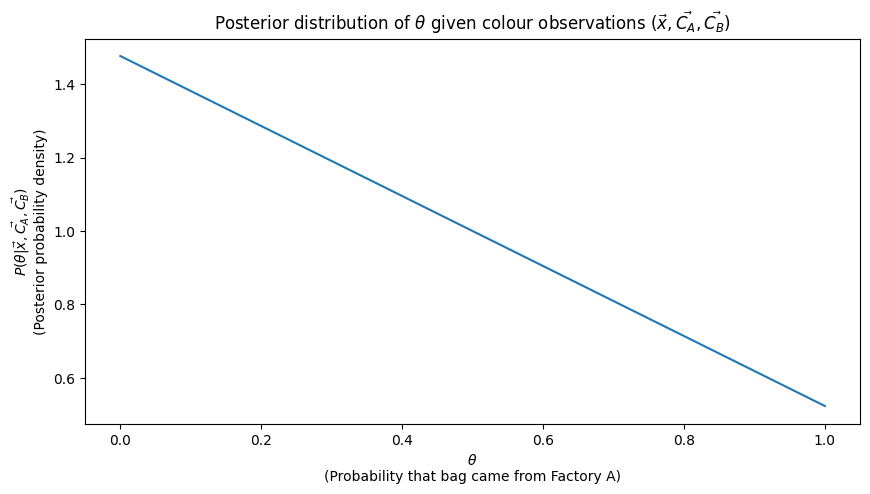

In [4]:
# plot
plt.figure(figsize=(10,5))
plt.plot(theta_arr, theta_pdf)

plt.title(r'Posterior distribution of $\theta$ given colour observations ($\vec{x}, \vec{C_A}, \vec{C_B}$)')
plt.xlabel(r'$\theta$' +'\n(Probability that bag came from Factory A)')
plt.ylabel(r'$P(\theta|\vec{x}, \vec{C_A}, \vec{C_B})$'+'\n(Posterior probability density)')

plt.show()